In [1]:
!pip install gymnasium
!pip install stable_baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.0 MB/s eta 0:00:00


In [15]:
!pip install swig
!pip install gymnasium[box2d] pyglet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.5 MB/s eta 0:00:00
  Using cached pyglet-2.1.13-py3-none-any.whl.metadata (7.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.6 MB/s eta 0:00:00


In [8]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

In [22]:
import gymnasium as gym
env=gym.make('CarRacing-v3', render_mode='rgb_array')

In [20]:
env.reset()

(array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 {})

In [21]:
env.action_space

Box([-1.  0.  0.], 1.0, (3,), float32)

In [25]:
env.observation_space
#obs space is an image

Box(0, 255, (96, 96, 3), uint8)

In [26]:
episodes=5
for episode in range(1,episodes+1):
    obs, info = env.reset()
    done=False
    score=0
    while not done:
      env.render()
      action=env.action_space.sample()
      obs,reward,terminated,truncated,info=env.step(action)
      done = terminated or truncated
      score+=reward
    print(episode,':', score)

1 : -29.68750000000043
2 : -27.536231884058243
3 : -31.271477663230737
4 : -39.39393939394003
5 : -33.56643356643399


array([[[101, 203, 101],
        [101, 203, 101],
        [101, 203, 101],
        ...,
        [101, 203, 101],
        [101, 203, 101],
        [101, 203, 101]],

       [[101, 203, 101],
        [101, 203, 101],
        [101, 203, 101],
        ...,
        [101, 203, 101],
        [101, 203, 101],
        [101, 203, 101]],

       [[101, 203, 101],
        [101, 203, 101],
        [101, 203, 101],
        ...,
        [101, 203, 101],
        [101, 203, 101],
        [101, 203, 101]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
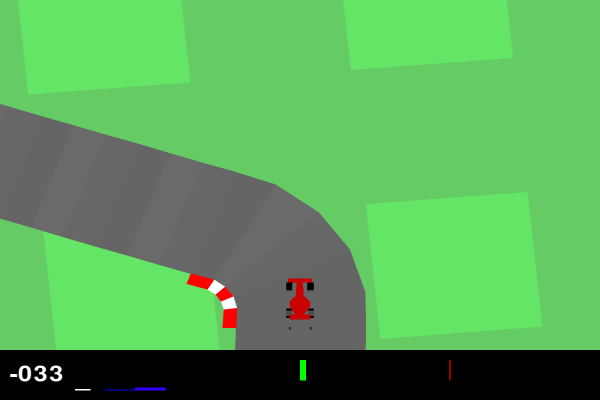

In [27]:
env.render() #is to visualize the agent's interaction with its environment

The goal is to get the car go along the race track!

In [28]:
env=gym.make('CarRacing-v3', render_mode='rgb_array')
env=DummyVecEnv([lambda: env])

In [32]:
import os
log_path=os.path.join('Training','Logs')
model=PPO('CnnPolicy', env, verbose=1, tensorboard_log=log_path)

Using cpu device
Wrapping the env in a VecTransposeImage.


In [33]:
model.learn(total_timesteps=10000)

Logging to Training/Logs/PPO_1
-----------------------------
| time/              |      |
|    fps             | 74   |
|    iterations      | 1    |
|    time_elapsed    | 27   |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 43         |
|    iterations           | 2          |
|    time_elapsed         | 94         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00679553 |
|    clip_fraction        | 0.0756     |
|    clip_range           | 0.2        |
|    entropy_loss         | -4.24      |
|    explained_variance   | 0.00315    |
|    learning_rate        | 0.0003     |
|    loss                 | 0.209      |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.00637   |
|    std                  | 0.992      |
|    value_loss           | 0.721      |
---------------------

In [34]:
#saving model
ppo_path= os.path.join('Training','Saved Models','PPO_Driving_Model')
model.save(ppo_path)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'Training/Saved Models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


In [35]:
evaluate_policy(model, env, n_eval_episodes=10, render=True)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


(np.float64(-50.54437688961625), np.float64(15.938039347076721))

In [38]:
#testing
episodes =8
for episode in range(1,episodes+1):
  obs=env.reset()
  done=False
  score=0
  while not done:
    env.render()
    action,_=model.predict(obs)  #using the model here now
    obs,reward,done,info=env.step(action)
    score+=reward
  print('Episode:{} Score:{}'.format(episode,score))

Episode:1 Score:[-51.07018]
Episode:2 Score:[-66.55476]
Episode:3 Score:[-48.051846]
Episode:4 Score:[-45.736366]
Episode:5 Score:[-49.843147]
Episode:6 Score:[-67.426254]
Episode:7 Score:[-40.199234]
Episode:8 Score:[-56.139885]


The scores are still negative here. But on increasing the training period, the results turn out to be better. But it requires a lot of time. Increasing the total_timesteps should work!